# Часть 1. Анализ дифференциальной экспрессии (DESeq2)

## Введение

В данном задании мы анализируем данные, которые исходно представляют собой матрицу сырых каунтов (число прочтений на ген) для набора образцов пациентов, проходивших терапию ICI (immune checkpoint inhibitors).
Задача анализа - выявить закономерности в экспрессии генов между группами пациентов с ответом (R) и без ответа (NR) на лечение, а также оценить качество данных и наличие выбросов.

Мы подразделили задачу на следующие этапы:
- нормализацию каунтов для устранения технических различий
- визуализации структуры данных (PCA)
- кластеризацию образцов (clustermap)
- последующий анализ дифференциальной экспрессии

## Исходные данные

Файл: raw_counts_ici_samples.tsv — матрица каунтов (гены $\times$ образцы)

Метаданные: meta_responses.tsv — таблица с группами образцов (R/NR)

Количество образцов: соответствует числу колонок в матрице каунтов

Количество генов: соответствует числу строк

## Нормализация данных

Изначально необходимо выполнить нормализацию данных RNA-seq. Нормализация данных - обязательный этап подготовки к анализу экспрессии генов, поскольку сырые каунты напрямую зависят от технических параметров эксперимента. Разное количество прочтений между образцами, различия в длине транскриптов и общий уровень экспрессии могут создавать ложные различия, не связанные с биологическими процессами. Без нормализации сравнение между образцами было бы некорректным, так как наблюдаемые различия могли бы отражать не биологические эффекты, а технические артефакты секвенирования.

Для устранения этих искажений мы воспользовались DESeq2 из Bioconductor. Метод DESeq2 основан на вычислении size factors, которые масштабируют каунты каждого образца относительно медианного уровня экспрессии по всем генам. Таким образом, каждый образец приводится к единой шкале, что делает значения экспрессии сопоставимыми между образцами. После нормализации данные отражают реальные биологические различия, а не технические вариации. Итоговая матрица нормализованных значений сохранена в файле normalized_counts_ici_samples.tsv, который используется для последующих этапов анализа.



## PCA

PCA - это метод снижения размерности, который позволяет свести многомерные данные экспрессии к нескольким главным компонентам, отражающим основные направления вариации. Такой подход помогает визуализировать структуру данных, выявить выбросы, оценить однородность образцов и проверить, разделяются ли группы пациентов с ответом (R) и без ответа (NR) на терапию.

Перед выполнением PCA данные были подвергнуты лог‑трансформации по формуле:
$$\text{log}_2(\text{normalized counts} + 1)$$

что стабилизирует дисперсию и делает распределение значений ближе к нормальному. Это особенно важно для RNA-seq, где диапазон каунтов может варьировать на несколько порядков.

Реализация сделана на питоне:

In [ ]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from adjustText import adjust_text

#Загрузка данных
normalized_counts = pd.read_csv('normalized_counts_ici_samples.tsv', sep='\t', index_col=0)
meta = pd.read_csv('meta_responses.tsv', sep='\t', index_col=0)

#Приведение имен
meta = meta.rename(columns={'0': 'X0'})
meta = meta[meta['X0'].isin(['R', 'NR'])]

normalized_counts.columns = normalized_counts.columns.str.replace('-', '.')
meta.index = meta.index.str.replace('-', '.')

#Согласование образцов
normalized_counts = normalized_counts[meta.index]
assert all(normalized_counts.columns == meta.index)

#Лог-трансформация
log_counts = np.log2(normalized_counts + 1)

#PCA
pca = PCA(n_components=2)
pca_res = pca.fit_transform(log_counts.T)
expl_var = pca.explained_variance_ratio_

#Цвета по группам
colors = meta['X0'].map({'R': 'tomato', 'NR': 'royalblue'})

#Визуализация
plt.figure(figsize=(10, 6))
plt.scatter(pca_res[:, 0], pca_res[:, 1], c=colors, s=40, alpha=0.85)

#Подписи только для выбросов
annotations = []
for i, label in enumerate(log_counts.columns):

    #Уникальное имя
    clean_label = label.split("_R1")[0]

    #Критерий выброса
    if abs(pca_res[i, 0]) > np.percentile(abs(pca_res[:, 0]), 80) or \
       abs(pca_res[i, 1]) > np.percentile(abs(pca_res[:, 1]), 80):

        annotations.append(
            plt.text(pca_res[i, 0], pca_res[i, 1], clean_label,
                     fontsize=9, ha='center', va='center',
                     bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))
        )

adjust_text(annotations, arrowprops=dict(arrowstyle='->', color='gray', lw=0.7))

#Оформление
plt.xlabel(f'PC1 ({expl_var[0]*100:.1f}%)', fontsize=13)
plt.ylabel(f'PC2 ({expl_var[1]*100:.1f}%)', fontsize=13)
plt.title('PCA of log2(normalized counts)', fontsize=15)
plt.grid(alpha=0.3)

for group, color in {'R': 'tomato', 'NR': 'royalblue'}.items():
    plt.scatter([], [], c=color, label=group)

plt.legend(title='Response group', loc='upper right', frameon=True)
plt.tight_layout()
plt.show()


Был получен следующий график:

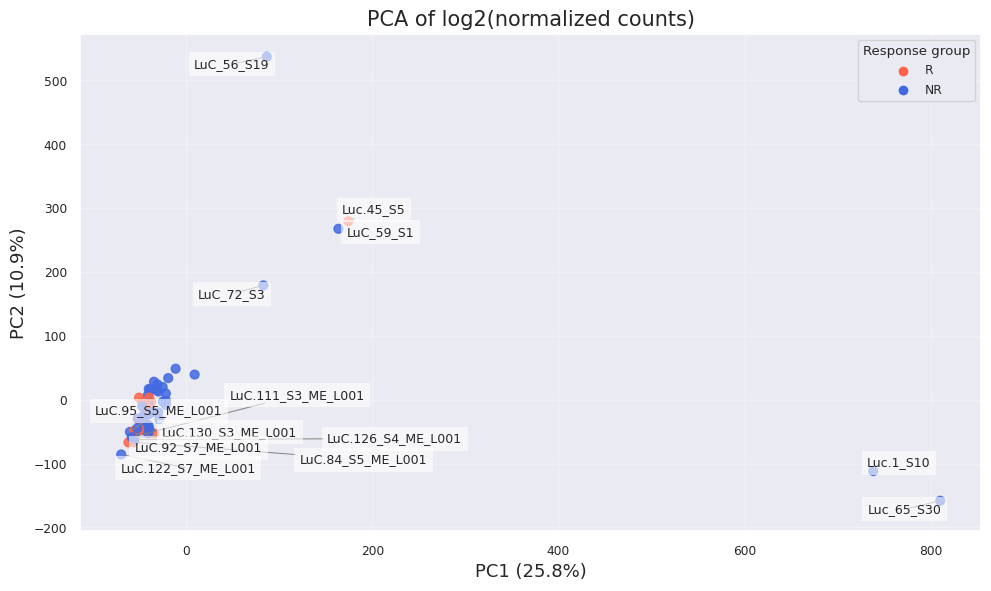

На полученном графике видно, что первая главная компонента (PC1) объясняет 25.8% общей вариации, а вторая (PC2) - 10.9%. Большинство образцов формируют плотный кластер вблизи центра, что свидетельствует о высокой однородности данных и корректной нормализации. Несколько образцов, таких как LuC_56_S19, LuC.1_S10, LuC_65_S30 - расположены далеко от основной группы, что указывает на возможные выбросы. Эти образцы стоило бы дополнительно проверить по качественным метрикам (FastQC, MultiQC), чтобы исключить технические артефакты. Поскольку выбросы на PCA не обязательно являются артефактами и не всегда требуют удаления, было принято решение сохранить их в дальнейшем анализе. Эти образцы не нарушают общую структуру данных и не влияют на интерпретацию PCA, поэтому их присутствие не является критичным для последующих этапов анализа.

## Сlustermap

Clustermap представляет собой визуализацию, объединяющую тепловую карту экспрессии генов и иерархическую кластеризацию образцов.
Для построения использовались нормализованные значения экспрессии (normalized_counts_ici_samples.tsv), полученные после DESeq2-нормализации, и метаданные (meta_responses.tsv), содержащие принадлежность образцов к группам пациентов с ответом (R) и без ответа (NR) на терапию.

Данные были были лог‑трансформированы аналогичным для построения PCA-способом. После чего были выбраны 500 наиболее вариабельных генов, то есть те, у которых разброс экспрессии между образцами максимален. Такой подход позволяет сосредоточиться на генах, наиболее информативных для различий между группами, и исключить маловариабельные транскрипты, не влияющие на структуру данных.

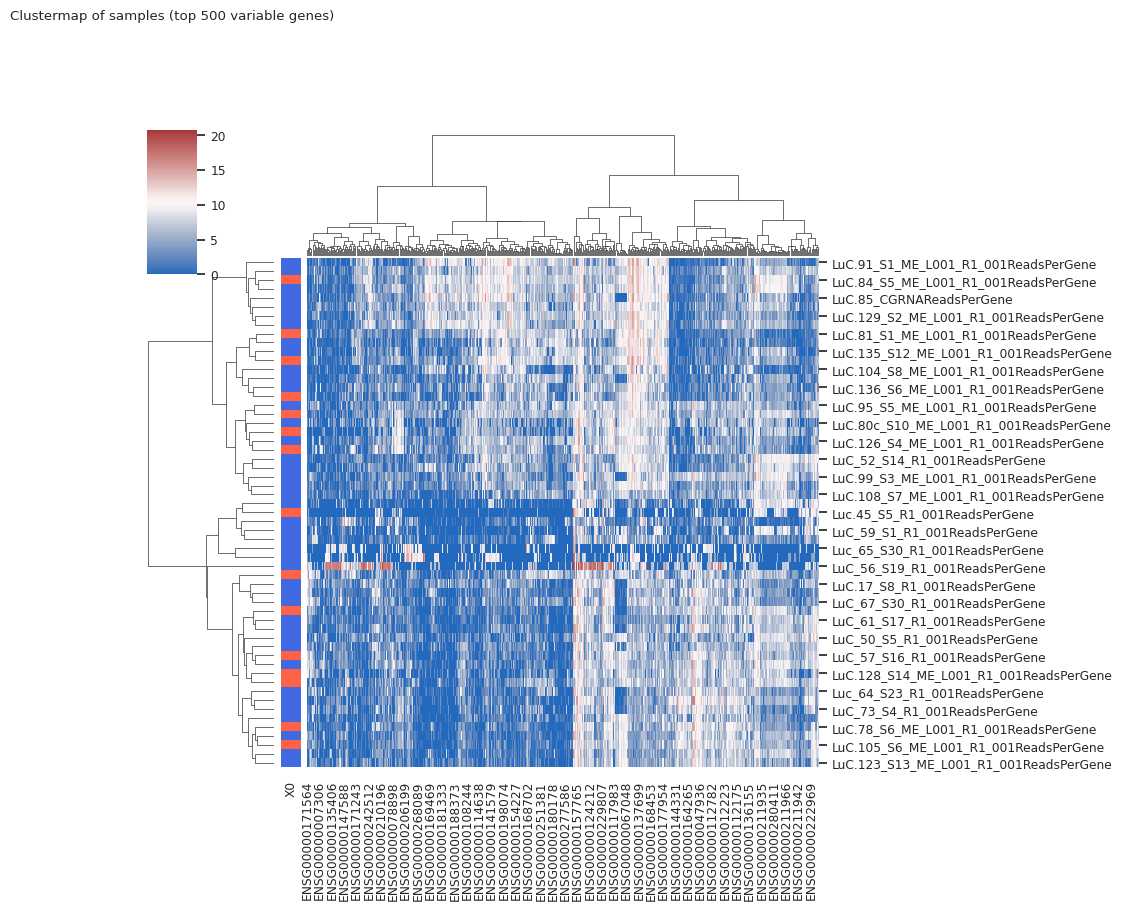

На полученной карте видно, что большинство образцов образуют плотные кластеры, что подтверждает высокую однородность данных и отсутствие выраженного batch effect. Образцы групп R и NR частично разделяются, что указывает на наличие биологических различий в профилях экспрессии. При этом отдельные образцы из разных групп могут кластеризоваться близко друг к другу, что отражает индивидуальные особенности транскриптомов пациентов.

Таким образом, clustermap демонстрирует, что данные RNA-seq после нормализации имеют стабильную структуру, а различия между группами R и NR проявляются на уровне экспрессии наиболее вариабельных генов. Это подтверждает корректность предварительной обработки и служит основанием для дальнейшего анализа дифференциальной экспрессии.

## Анализ дифференциально экспрессированных генов

Перед запуском основного анализа дифференциальной экспрессии уровень фактора X0 был переопределён так, чтобы группа NR использовалась в качестве референсной:

`dds$X0 <- relevel(dds$X0, ref = "NR")`

Это означает, что все оценки log2 fold change будут интерпретироваться как изменение экспрессии в группе R относительно группы NR. После этого был вызван основной рабочий конвейер DESeq2 с помощью функции DESeq(dds), которая последовательно оценивает дисперсии, подгоняет обобщенные линейные модели для каждого гена и выполняет статистические тесты на дифференциальную экспрессию между группами.

Результаты анализа были получены функцией results(dds), которая возвращает для каждого гена оценку логарифма отношения экспрессий (столбец log2FoldChange), сырой p-value и padj, рассчитанное с поправкой Бенджамини–Хохберга.

Объект результатов был преобразован в обычный data.frame (res_df), после чего из него были удалены строки с пропущенными значениями padj или log2FoldChange, чтобы избежать проблем при визуализации и последующей фильтрации.

Для удобства интерпретации генов по их символам, а не только по Ensembl-идентификаторам, была загружена таблица соответствий из файла hgnc_complete_set.txt, содержащего сопоставление Ensembl ID и HGNC-символов. На основе этой таблицы был создан словарь symbol_map, и для каждого гена в res_df был добавлен новый столбец Gene, в котором, если это возможно, Ensembl-идентификатор заменялся на соответствующий HGNC-символ. В случаях, когда соответствие отсутствовало, в качестве имени гена оставлялся исходный идентификатор.

Далее был задан порог значимости для отбора дифференциально экспрессированных генов:  padj < 0.01 и модуль логарифма отношения экспрессий |log2FoldChange| > 3. На основе этих критериев в таблицу результатов был добавлен столбец significance, принимающий значения "Significant" или "Not Significant", в зависимости от того, удовлетворяет ли ген указанным порогам. Это позволило разделить гены на статистически значимо дифференциально экспрессированные и незначимые.


## Volcano plot

В ходе анализа дифференциальной экспрессии между группами пациентов с ответом на терапию (R) и без ответа (NR) был построен volcano plot, который позволяет одновременно оценить статистическую значимость и величину изменений экспрессии генов. На оси X отложен показатель log2 Fold Change, отражающий степень изменения экспрессии в группе R относительно NR, а на оси Y - -log10 padj, характеризующий уровень статистической достоверности после поправки на множественное тестирование.

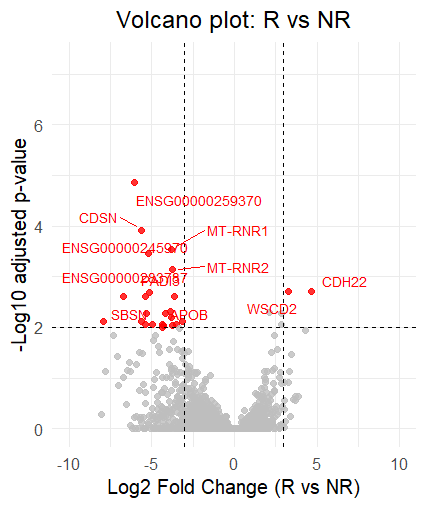

Большинство генов расположено в центральной области графика, что указывает на отсутствие значимых различий их экспрессии между группами. Эти гены имеют низкие значения log2 Fold Change и высокие padj, то есть изменения их уровня экспрессии статистически несущественны. По краям графика видны отдельные красные точки, соответствующие генам, которые демонстрируют достоверные различия (padj < 0.01 и |log2 Fold Change| > 3). Они находятся за пределами пунктирных пороговых линий и характеризуются высокой степенью статистической значимости.

Среди наиболее значимых генов выделяются MT-RNR1, MT-RNR2, CDSN, SBSN, WSCD2, CDH22, APOB, а также несколько генов, представленных Ensembl-идентификаторами. Гены с отрицательным log2 Fold Change (левая часть графика) имеют пониженную экспрессию в группе R по сравнению с NR, а гены с положительным log2 Fold Change (правая часть) - повышенную.

Таким образом, volcano plot показывает, что подавляющее большинство генов имеет сходные уровни экспрессии между группами, однако существует ограниченное число транскриптов, демонстрирующих статистически и биологически значимые различия. Эти гены представляют интерес для дальнейшего функционального анализа, так как могут быть вовлечены в механизмы ответа на лечение и служить потенциальными биомаркерами эффективности терапии.

## Выводы

В ходе анализа RNA-seq данных пациентов, проходивших терапию ингибиторами контрольных точек иммунного ответа (ICI), были получены следующие основные выводы:
1. Нормализация прошла корректно, большинство образцов демонстрируют высокую однородность и отсутствие выраженного batch-effect. Это подтверждается плотным кластером на PCA и clustermap.
2. частичное разделение групп R и NR на PCA и clustermap отражает наличие биологических различий в профилях экспрессии, хотя полное разделение отсутствует, что типично для клинических данных.
3. выявлены гены с достоверными изменениями экспрессии между группами (padj < 0.01, |log2FC| > 3). Среди них — MT-RNR1, MT-RNR2, CDSN, SBSN, WSCD2, CDH22, APOB.

Данные RNA-seq обладают высоким качеством и биологической информативностью. Различия между группами R и NR проявляются в ограниченном наборе генов, которые могут служить потенциальными биомаркерами ответа на лечение и основой для дальнейшего функционального анализа.



# Часть 2.

## Введение

В этом задании проводился анализ дифференциальной экспрессии генов между группами пациентов с полным/частичным ответом на химиотерапию (pCR) и без ответа (pNC) на основе данных микрочипов GEO-набора GSE63885. Для анализа использовался пакет limma, поскольку он специально разработан для микрочипов и нормализованных RNA-seq данных, метод основан на линейных моделях и использует эмпирическую модерацию дисперсий, что важно при небольшом числе образцов, как у нас. В отличие от методов, работающих с сырыми каунтами, limma обеспечивает более стабильные и надежные оценки при работе с непрерывными значениями экспрессии и позволяет корректно сравнивать группы даже при высокой вариабельности данных.

## Limma

Все дальнейшие шаги производились при помощи языка программирования R. После подгонки модели была получена таблица результатов (topTable) с оценками logFC, p-value и padj. Для оценки влияния порога fold change были выбраны три значения: |logFC| > 1, |logFC| > 2 и |logFC| > 3.

При использовании скорректированных p-значений (padj < 0.05) для всех порогов количество значимых генов оказалось равным нулю. Это говорит о том, что после поправки Бенджамини–Хохберга различия между группами не достигают строгой статистической значимости, вероятно из‑за небольшого размера выборки и высокой внутригрупповой вариации, что также видно на построенных volcano plots.

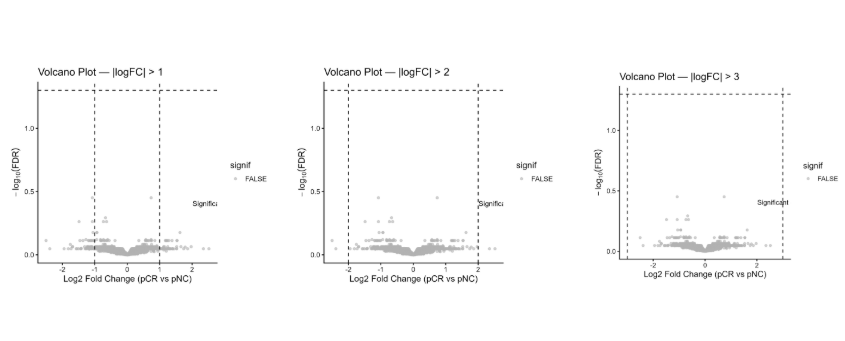

Поэтому для визуализации и предварительной интерпретации использовались сырые p-значения (p-value < 0.05), что позволяет выявить потенциально интересные гены, которые могут быть биологически значимыми, даже если они не проходят строгую коррекцию. Такой подход может быть оправдан на этапах начального анализа, когда целью является определение направления для дальнейшей проверки, а не окончательные статистические выводы.

В этом случае также были построены volcano-plots



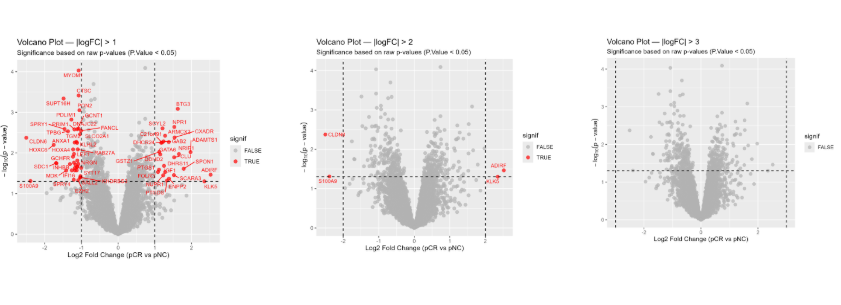

На volcano plot при пороге |logFC| > 3 значимых генов не наблюдается, при |logFC| > 2 выделяются несколько транскриптов (CLDN6, S100A9, ADIRF, KLK5), а при |logFC| > 1 более широкий набор генов (MYOM1, CTSC, PDLIM1, HOXC6, LEF1, NRGN, BTG3, GATA6, IGF1, CLU, ENPP2, KLK5 и др.).

Сравнение графиков показывает, что порог |logFC| > 1 является оптимальным для данного анализа. Он обеспечивает баланс между числом найденных генов и биологической интерпретируемостью результатов, именно при этом пороге выявляется достаточное количество кандидатов, но сохраняется фокус на транскриптах с заметными изменениями экспрессии.

В случае же например |logFC| > 2 порог оказывается слишком строгим, так как при его использовании число выявленных генов резко сокращается, и volcano plot фактически теряет информативность, на графике остаются лишь единичные точки, что может не позволить провести содержательную биологическую интерпретацию.



В итоговой таблице limma_diffexp_results_with_significance.csv были собраны результаты для всех трех порогов logFC, включая количество значимых генов и бинарные столбцы signif_logFC1, signif_logFC2, signif_logFC3, отражающие, проходит ли ген критерий значимости при каждом пороге.

## Выводы

limma показала, что после анализа с поправкой на множественные тестирования статистически значимых генов нет, однако анализ сырых p-values выявил ряд транскриптов, потенциально связанных с клиническим ответом. Наиболее подходящим порогом для интерпретации оказался |logFC| > 1, поскольку он обеспечивает баланс между числом найденных генов и биологической интерпретируемостью результатов. Эти гены могут быть использованы для дальнейшего анализа и проверки гипотез о механизмах ответа на терапию.